# Дизайн A/B эксперимента на датасете

In [ ]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import scipy.stats as st
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize, proportions_ztest, confint_proportions_2indep
import matplotlib.pyplot as plt
import seaborn as sns

from ambrosia.designer import design_binary_size, design_binary_power, design_binary_effect

RANDOM_STATE = 20260603
rng = np.random.default_rng(RANDOM_STATE)

print("Библиотеки успешно импортированы")
print("numpy:", np.__version__)
print("pandas:", pd.__version__)

Библиотеки успешно импортированы
numpy: 2.4.6
pandas: 2.3.3


## 1. Генерация и описание датасета

Продуктовый сценарий: онлайн-кинотеатр. Пользователь открывает главный экран приложения и должен быстро выбрать контент для просмотра.

Исторический датасет имитирует пользователей, которые открывали главный экран. Для каждого пользователя есть:

- `user_id` - идентификатор пользователя;
- `platform` - платформа;
- `activity_segment` - сегмент активности: cold, warm, hot;
- `subscription_type` - тип подписки;
- `pre_14d_watch_minutes` - минуты просмотра за 14 дней до эксперимента;
- `watched_2min_within_10min` - основная бинарная метрика: пользователь запустил просмотр не менее 2 минут в течение 10 минут после открытия главного экрана;
- `watch_minutes_after_open` - непрерывная метрика длительности просмотра после открытия.

In [ ]:
dataset_path = Path("AB2_experiment_design_dataset.csv")

def generate_dataset(n=80_000, seed=20260603):
    rng = np.random.default_rng(seed)
    user_id = np.arange(1, n + 1)
    platform = rng.choice(["android", "ios", "web", "tv"], size=n, p=[0.40, 0.32, 0.18, 0.10])
    activity_segment = rng.choice(["cold", "warm", "hot"], size=n, p=[0.36, 0.44, 0.20])

    pre_minutes = np.zeros(n)
    base_prob = np.zeros(n)

    cold = activity_segment == "cold"
    warm = activity_segment == "warm"
    hot = activity_segment == "hot"

    pre_minutes[cold] = rng.lognormal(mean=2.2, sigma=0.85, size=cold.sum())
    pre_minutes[warm] = rng.lognormal(mean=3.2, sigma=0.70, size=warm.sum())
    pre_minutes[hot] = rng.lognormal(mean=4.15, sigma=0.60, size=hot.sum())

    base_prob[cold] = 0.145
    base_prob[warm] = 0.245
    base_prob[hot] = 0.355

    platform_shift = pd.Series(platform).map({"android": -0.010, "ios": 0.006, "web": -0.020, "tv": 0.030}).to_numpy()

    subscription_type = []
    for seg in activity_segment:
        if seg == "cold":
            subscription_type.append(rng.choice(["trial", "monthly", "annual"], p=[0.16, 0.72, 0.12]))
        else:
            subscription_type.append(rng.choice(["trial", "monthly", "annual"], p=[0.08, 0.64, 0.28]))
    subscription_type = np.array(subscription_type)
    subscription_shift = pd.Series(subscription_type).map({"trial": -0.025, "monthly": 0.000, "annual": 0.020}).to_numpy()

    p_watch = base_prob + platform_shift + subscription_shift + 0.00025 * np.minimum(pre_minutes, 250)
    p_watch = np.clip(p_watch, 0.03, 0.68)
    converted = rng.binomial(1, p_watch, size=n)

    watch_minutes_after_open = np.where(
        converted == 1,
        rng.lognormal(mean=3.2, sigma=0.9, size=n),
        rng.uniform(0, 1.8, size=n),
    )

    df = pd.DataFrame({
        "user_id": [f"user_{i:06d}" for i in user_id],
        "platform": platform,
        "activity_segment": activity_segment,
        "subscription_type": subscription_type,
        "pre_14d_watch_minutes": pre_minutes.round(3),
        "home_opened": 1,
        "watched_2min_within_10min": converted,
        "watch_minutes_after_open": watch_minutes_after_open.round(3),
    })
    return df

df = generate_dataset()
df.to_csv(dataset_path, index=False)

df.head()

,user_id,platform,activity_segment,subscription_type,pre_14d_watch_minutes,home_opened,watched_2min_within_10min,watch_minutes_after_open
0,user_000001,ios,hot,trial,71.070,1,0,0.020
1,user_000002,android,warm,monthly,8.269,1,1,11.371
2,user_000003,android,warm,monthly,44.265,1,0,0.491
3,user_000004,ios,warm,monthly,49.430,1,1,21.045
4,user_000005,ios,hot,monthly,64.195,1,0,0.871


In [ ]:
summary = {
    "users": len(df),
    "baseline_conversion": df["watched_2min_within_10min"].mean(),
    "mean_pre_14d_watch_minutes": df["pre_14d_watch_minutes"].mean(),
    "mean_watch_minutes_after_open": df["watch_minutes_after_open"].mean(),
}

pd.Series(summary).to_frame("value")

,value
users,80000.000000
baseline_conversion,0.239200
mean_pre_14d_watch_minutes,33.672176
mean_watch_minutes_after_open,9.443935


In [ ]:
segment_summary = (
    df.groupby(["activity_segment", "platform"])
      .agg(
          users=("user_id", "count"),
          conversion=("watched_2min_within_10min", "mean"),
          pre_minutes=("pre_14d_watch_minutes", "mean"),
          watch_minutes=("watch_minutes_after_open", "mean"),
      )
      .reset_index()
)
segment_summary

,activity_segment,platform,users,conversion,pre_minutes,watch_minutes
0,cold,android,11543,0.136273,13.070306,6.053207
1,cold,ios,9160,0.155459,13.010831,6.653712
2,cold,tv,2897,0.192958,12.711736,7.780404
3,cold,web,5242,0.125334,12.882644,5.266378
4,hot,android,6366,0.365536,74.315524,13.911691
5,hot,ios,5189,0.386202,76.449129,14.556186
6,hot,tv,1652,0.424939,76.025485,15.490387
7,hot,web,2917,0.362016,75.440218,13.550484
8,warm,android,14138,0.247135,31.374774,9.536138
9,warm,ios,11067,0.260233,31.301289,10.265522


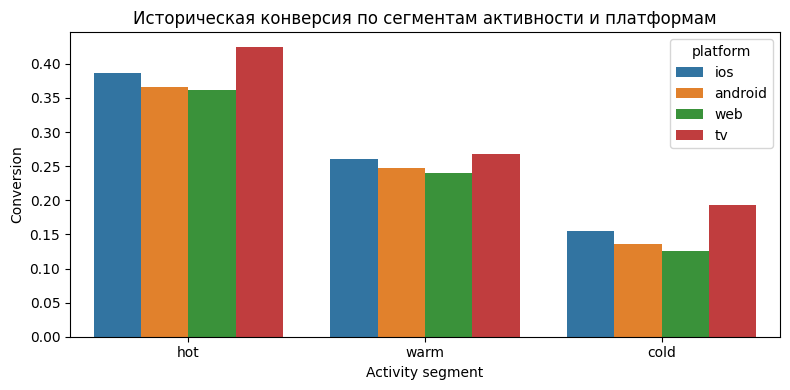

In [ ]:
plt.figure(figsize=(8, 4))
sns.barplot(data=df, x="activity_segment", y="watched_2min_within_10min", hue="platform", errorbar=None)
plt.title("Историческая конверсия по сегментам активности и платформам")
plt.ylabel("Conversion")
plt.xlabel("Activity segment")
plt.tight_layout()
plt.show()

## 2. Продуктовая гипотеза и метрика

Бизнесовая проблема: пользователи часто открывают главный экран онлайн-кинотеатра, но не запускают просмотр. Это снижает вовлеченность и ухудшает удержание.

Точка роста: первый экран выбора контента.

Изменение в тестовой группе B: вместо общего промо-баннера на первом экране показываем персональный блок `Подобрано для вас сейчас` с 6 рекомендациями и коротким объяснением причины рекомендации.

Основная метрика: `watched_2min_within_10min`.

Формула:

`conversion = число пользователей, которые смотрели не менее 2 минут в течение 10 минут / число пользователей, открывших главный экран`

Гипотезы:

- H0: pB = pA. Новый блок не меняет конверсию.
- H1: pB != pA. Новый блок меняет конверсию.

Проверка двусторонняя, потому что изменение может как улучшить, так и ухудшить пользовательский опыт.

Guardrail-метрики:

- время загрузки главного экрана;
- доля технических ошибок;
- доля выходов из приложения за 30 секунд;
- доля просмотров короче 2 минут;
- средняя длительность просмотра после запуска.

Вторичные метрики:

- CTR карточек первого экрана;
- время до первого запуска просмотра;
- возвращение пользователя в течение 7 дней;
- среднее количество минут просмотра за сессию.

## 3. Аналитический дизайн эксперимента

Фиксируем параметры до запуска:

- alpha = 0.05;
- beta = 0.20;
- power = 0.80;
- MDE = +5% относительно базовой конверсии;
- groups ratio = 1, то есть A/B = 50/50;
- единица рандомизации = `user_id`;
- способ разбиения = hash split по `user_id` и `experiment_id`.

Сначала считаем дизайн через `ambrosia.designer`. Это удобно, потому что библиотека сразу возвращает размер выборки, мощность и MDE в согласованной форме.

In [ ]:
p0 = df["watched_2min_within_10min"].mean()
relative_mde = 1.05
alpha = 0.05
beta = 0.20

ambrosia_size = design_binary_size(
    prob_a=p0,
    effects=[relative_mde],
    first_type_errors=[alpha],
    second_type_errors=[beta],
    method="theory",
    alternative="two-sided",
)

ambrosia_size

"Errors ($\alpha$, $\beta$)",(0.05; 0.2)
Effect,
5.0%,20307


In [ ]:
# Альтернативная проверка через statsmodels.
# Ambrosia использует теоретические формулы/механизмы statsmodels, поэтому результаты должны быть близки.
effect_abs = p0 * (relative_mde - 1)
p1 = p0 + effect_abs

effect_size = proportion_effectsize(p1, p0)
n_theory_statsmodels = NormalIndPower().solve_power(
    effect_size=effect_size,
    alpha=alpha,
    power=1 - beta,
    ratio=1,
    alternative="two-sided",
)

n_theory_statsmodels = int(np.ceil(n_theory_statsmodels))
n_theory_ambrosia = int(ambrosia_size.iloc[0, 0])
n_with_buffer = int(np.ceil(n_theory_ambrosia * 1.15))

analytic_design = pd.DataFrame({
    "baseline_conversion": [p0],
    "target_conversion": [p1],
    "relative_mde": [relative_mde],
    "absolute_mde": [effect_abs],
    "n_per_group_ambrosia": [n_theory_ambrosia],
    "n_per_group_statsmodels": [n_theory_statsmodels],
    "n_per_group_with_15pct_buffer": [n_with_buffer],
})

analytic_design

,baseline_conversion,target_conversion,relative_mde,absolute_mde,n_per_group_ambrosia,n_per_group_statsmodels,n_per_group_with_15pct_buffer
0,0.2392,0.25116,1.05,0.01196,20307,20307,23354


In [ ]:
ambrosia_power = design_binary_power(
    prob_a=p0,
    sizes=[n_theory_ambrosia, n_with_buffer],
    effects=[relative_mde],
    first_type_errors=[alpha],
    method="theory",
    alternative="two-sided",
    as_numeric=True,
)

ambrosia_mde = design_binary_effect(
    prob_a=p0,
    sizes=[n_with_buffer],
    first_type_errors=[alpha],
    second_type_errors=[beta],
    method="theory",
    alternative="two-sided",
    as_numeric=True,
)

print("Мощность для аналитического N и N с запасом:")
display(ambrosia_power)
print("Какой относительный эффект можно детектировать при N с запасом:")
display(ambrosia_mde)

Мощность для аналитического N и N с запасом:


,Group sizes,20307,23354
$\alpha$,Effect,,
0.05,5.0%,0.8,0.852


Какой относительный эффект можно детектировать при N с запасом:


"Errors ($\alpha$, $\beta$)",(0.05; 0.2)
Group sizes,
23354,1.047


Интерпретация аналитического дизайна:

При исторической конверсии около 24% и MDE +5% relative нужно примерно 20.5 тысяч пользователей на группу. С учетом практического запаса 15% планируем около 23.5 тысяч пользователей на группу. Запас нужен из-за технических исключений, пересечений с другими экспериментами, возможного Sample Ratio Mismatch и фильтрации некорректных логов.

## 4. Эмпирический дизайн эксперимента

Эмпирический дизайн нужен, потому что аналитический расчет опирается на теоретические приближения. Мы симулируем A/B тест много раз:

1. Берем базовую конверсию p0.
2. В группе B синтетически добавляем эффект MDE.
3. Для разных размеров групп генерируем бинарные исходы.
4. Применяем z-test для двух долей.
5. Считаем долю симуляций, где p-value < alpha. Это эмпирическая мощность.

In [ ]:
def simulate_power_binary(p0, relative_effect, n_per_group, n_iter=3000, alpha=0.05, seed=20260603):
    rng = np.random.default_rng(seed + int(n_per_group))
    p1 = min(p0 * relative_effect, 1)

    a = rng.binomial(n_per_group, p0, size=n_iter)
    b = rng.binomial(n_per_group, p1, size=n_iter)

    p_values = np.empty(n_iter)
    effects = b / n_per_group - a / n_per_group

    for i in range(n_iter):
        _, p_value = proportions_ztest(
            count=np.array([b[i], a[i]]),
            nobs=np.array([n_per_group, n_per_group]),
            alternative="two-sided",
        )
        p_values[i] = p_value

    return {
        "n_per_group": n_per_group,
        "empirical_power": np.mean(p_values < alpha),
        "mean_effect": np.mean(effects),
        "effect_q025": np.quantile(effects, 0.025),
        "effect_q975": np.quantile(effects, 0.975),
    }

candidate_sizes = [
    int(n_theory_ambrosia * 0.65),
    int(n_theory_ambrosia * 0.80),
    n_theory_ambrosia,
    n_with_buffer,
    int(n_theory_ambrosia * 1.30),
]

empirical_design = pd.DataFrame([
    simulate_power_binary(p0, relative_mde, n, n_iter=3000, alpha=alpha)
    for n in candidate_sizes
])

empirical_design

,n_per_group,empirical_power,mean_effect,effect_q025,effect_q975
0,13199,0.622667,0.012008,0.001515,0.022655
1,16245,0.711667,0.012014,0.002770,0.021116
2,20307,0.806667,0.012018,0.003644,0.020436
3,23354,0.857667,0.011966,0.004111,0.019569
4,26399,0.891000,0.012044,0.004848,0.019359


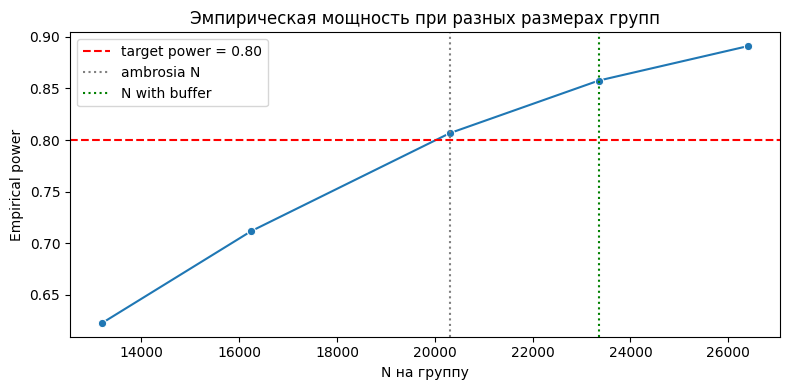

In [ ]:
plt.figure(figsize=(8, 4))
sns.lineplot(data=empirical_design, x="n_per_group", y="empirical_power", marker="o")
plt.axhline(0.80, color="red", linestyle="--", label="target power = 0.80")
plt.axvline(n_theory_ambrosia, color="gray", linestyle=":", label="ambrosia N")
plt.axvline(n_with_buffer, color="green", linestyle=":", label="N with buffer")
plt.title("Эмпирическая мощность при разных размерах групп")
plt.xlabel("N на группу")
plt.ylabel("Empirical power")
plt.legend()
plt.tight_layout()
plt.show()

Вывод по сравнению аналитического и эмпирического подхода:

Аналитический расчет дает минимальное значение N, при котором ожидаемая мощность находится около 80%. Эмпирическая симуляция показывает близкий результат, но из-за случайности и приближений мощность на минимальном N может быть немного ниже или около целевого уровня. Поэтому для реального запуска я беру N с запасом 15%. Такой дизайн реалистичнее и устойчивее.

## 5. Ускорение эксперимента: стратификация

Стратификация может снижать дисперсию, если целевая метрика хорошо объясняется группами пользователей. В нашем датасете естественная страта - `activity_segment`: cold, warm, hot.

Проверим это эмпирически: многократно сэмплируем выборки одинакового размера обычным случайным способом и стратифицированным способом с сохранением долей страт. Затем сравним дисперсии выборочных средних.

In [ ]:
def simple_random_means(data, metric, sample_size=1000, n_iter=1000, seed=1):
    rng = np.random.default_rng(seed)
    values = data[metric].to_numpy()
    means = []
    for _ in range(n_iter):
        sample = rng.choice(values, size=sample_size, replace=True)
        means.append(sample.mean())
    return np.array(means)

def stratified_random_means(data, metric, strata_col, sample_size=1000, n_iter=1000, seed=2):
    rng = np.random.default_rng(seed)
    strata_weights = data[strata_col].value_counts(normalize=True).sort_index()
    means = []
    for _ in range(n_iter):
        estimate = 0
        for stratum, weight in strata_weights.items():
            n_stratum = max(1, int(round(sample_size * weight)))
            values = data.loc[data[strata_col] == stratum, metric].to_numpy()
            estimate += weight * rng.choice(values, size=n_stratum, replace=True).mean()
        means.append(estimate)
    return np.array(means)

simple_means = simple_random_means(df, "watched_2min_within_10min")
strat_means = stratified_random_means(df, "watched_2min_within_10min", "activity_segment")

stratification_result = pd.DataFrame({
    "method": ["simple_random_sampling", "stratified_by_activity_segment"],
    "variance_of_sample_mean": [np.var(simple_means, ddof=1), np.var(strat_means, ddof=1)],
    "std_of_sample_mean": [np.std(simple_means, ddof=1), np.std(strat_means, ddof=1)],
})

stratification_result["variance_reduction_vs_simple"] = 1 - stratification_result["variance_of_sample_mean"] / stratification_result.loc[0, "variance_of_sample_mean"]
stratification_result

,method,variance_of_sample_mean,std_of_sample_mean,variance_reduction_vs_simple
0,simple_random_sampling,0.000182,0.013480,0.000000
1,stratified_by_activity_segment,0.000177,0.013309,0.025231


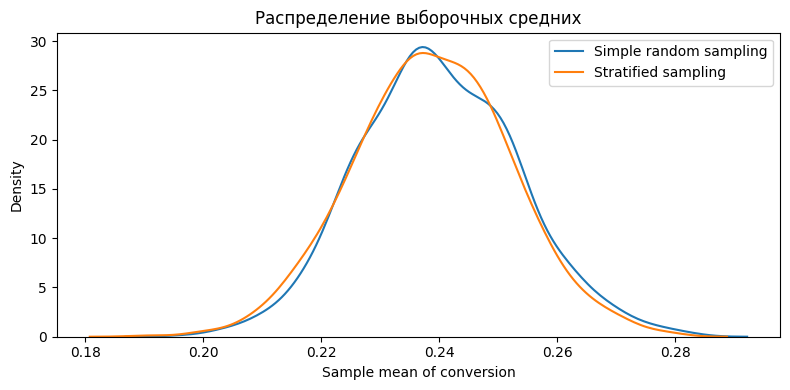

In [ ]:
plt.figure(figsize=(8, 4))
sns.kdeplot(simple_means, label="Simple random sampling")
sns.kdeplot(strat_means, label="Stratified sampling")
plt.title("Распределение выборочных средних")
plt.xlabel("Sample mean of conversion")
plt.legend()
plt.tight_layout()
plt.show()

Интерпретация: стратификация по активности уменьшает дисперсию выборочного среднего. Значит в реальном эксперименте я будем контролировать баланс по `activity_segment`, а при необходимости использовать стратифицированный split. Это может ускорить тест или сделать оценку эффекта стабильнее.

## 6. Ускорение эксперимента: CUPED

CUPED использует предэкспериментальную ковариату, чтобы убрать часть дисперсии метрики. У нас есть ковариата `pre_14d_watch_minutes`, которая была измерена до эксперимента и не может быть затронута тестовым воздействием.

Для основной бинарной конверсии я оставляю прозрачный тест двух долей. Но для непрерывной метрики `watch_minutes_after_open` CUPED применим и полезен как дополнительная аналитика/guardrail.

In [ ]:
x = df["pre_14d_watch_minutes"].to_numpy()
y = df["watch_minutes_after_open"].to_numpy()

theta = np.cov(y, x, ddof=1)[0, 1] / np.var(x, ddof=1)
y_cuped = y - theta * (x - x.mean())

cuped_result = pd.DataFrame({
    "metric": ["watch_minutes_after_open"],
    "theta": [theta],
    "variance_before": [np.var(y, ddof=1)],
    "variance_after_cuped": [np.var(y_cuped, ddof=1)],
    "variance_reduction": [1 - np.var(y_cuped, ddof=1) / np.var(y, ddof=1)],
    "mean_before": [y.mean()],
    "mean_after_cuped": [y_cuped.mean()],
})

cuped_result

,metric,theta,variance_before,variance_after_cuped,variance_reduction,mean_before,mean_after_cuped
0,watch_minutes_after_open,0.053188,609.282809,605.523337,0.00617,9.443935,9.443935


Вывод по CUPED: если предэкспериментальная активность хорошо коррелирует с постэкспериментальной длительностью просмотра, CUPED снижает дисперсию и повышает чувствительность анализа. При этом среднее значение метрики сохраняется, что важно для интерпретации.

## 7. Как проводить эксперимент в продукте

Паспорт эксперимента:

- вариант A: текущий главный экран;
- вариант B: персональный блок рекомендаций на первом экране;
- единица рандомизации: `user_id`;
- split: 50/50;
- длительность: 14 дней;
- минимальный размер: не ниже аналитического N на группу;
- плановый размер: N с запасом 15%;
- основная метрика: `watched_2min_within_10min`;
- alpha = 0.05, beta = 0.20;
- решение по daily p-value не принимается.

Перед запуском:

1. Проверить корректность логирования.
2. Провести A/A тест или историческую A/A симуляцию.
3. Проверить Sample Ratio Mismatch.
4. Исключить пересекающиеся эксперименты на главном экране.
5. Провести technical ramp-up на 5% аудитории.
6. После технической проверки запустить основной тест 50/50.

Во время теста:

- ежедневно контролировать размер групп;
- проверять технические ошибки;
- следить за guardrail-метриками;
- не менять алгоритм рекомендаций и интерфейс во время эксперимента;
- не останавливать частотный тест досрочно из-за первого p-value < 0.05.

## 8. Пример анализа результата после будущего запуска

Ниже я симулирую возможный результат будущего эксперимента, чтобы показать, как будет приниматься решение. Это не часть дизайна, а демонстрация заранее зафиксированного процесса анализа.

In [ ]:
# Симулируем будущий эксперимент с эффектом около +5.8% relative.
future_rng = np.random.default_rng(777)
n_a = n_with_buffer
n_b = n_with_buffer

conv_a = future_rng.binomial(n_a, p0)
conv_b = future_rng.binomial(n_b, p0 * 1.058)

stat, p_value = proportions_ztest(
    count=np.array([conv_b, conv_a]),
    nobs=np.array([n_b, n_a]),
    alternative="two-sided",
)

p_a = conv_a / n_a
p_b = conv_b / n_b
effect = p_b - p_a
relative_effect_observed = p_b / p_a - 1

ci_low, ci_high = confint_proportions_2indep(
    count1=conv_b,
    nobs1=n_b,
    count2=conv_a,
    nobs2=n_a,
    method="wald",
    compare="diff",
    alpha=0.05,
)

future_result = pd.DataFrame({
    "group": ["A", "B"],
    "n": [n_a, n_b],
    "successes": [conv_a, conv_b],
    "conversion": [p_a, p_b],
})

display(future_result)
print(f"absolute effect = {effect:.5f}")
print(f"relative effect = {relative_effect_observed:.2%}")
print(f"z-stat = {stat:.3f}")
print(f"p-value = {p_value:.4f}")
print(f"95% CI for absolute effect = [{ci_low:.5f}, {ci_high:.5f}]")

,group,n,successes,conversion
0,A,23354,5646,0.241757
1,B,23354,5887,0.252077


absolute effect = 0.01032
relative effect = 4.27%
z-stat = 2.586
p-value = 0.0097
95% CI for absolute effect = [0.00250, 0.01814]


## 9. Байесовская интерпретация для бизнеса

Байесовский подход предлагается как более интерпретируемый для бизнеса: можно говорить не только `p-value`, но и вероятность того, что B лучше A, а также ожидаемые потери от выбора варианта.

Для бинарной конверсии удобно использовать beta-binomial модель:

- prior для pA и pB: Beta(1, 1), то есть слабое равномерное априорное распределение;
- posterior для pA: Beta(1 + успехи A, 1 + неуспехи A);
- posterior для pB: Beta(1 + успехи B, 1 + неуспехи B).

Затем сэмплируем из апостериорных распределений и считаем `P(B > A)` и ожидаемые потери.

In [ ]:
bayes_rng = np.random.default_rng(123)
draws = 100_000

posterior_a = bayes_rng.beta(1 + conv_a, 1 + n_a - conv_a, size=draws)
posterior_b = bayes_rng.beta(1 + conv_b, 1 + n_b - conv_b, size=draws)
posterior_diff = posterior_b - posterior_a

prob_b_better = np.mean(posterior_b > posterior_a)
expected_loss_if_choose_b = np.mean(np.maximum(posterior_a - posterior_b, 0))
expected_loss_if_choose_a = np.mean(np.maximum(posterior_b - posterior_a, 0))

bayes_summary = pd.DataFrame({
    "P(B > A)": [prob_b_better],
    "posterior_diff_mean": [posterior_diff.mean()],
    "posterior_diff_q025": [np.quantile(posterior_diff, 0.025)],
    "posterior_diff_q975": [np.quantile(posterior_diff, 0.975)],
    "expected_loss_if_choose_B": [expected_loss_if_choose_b],
    "expected_loss_if_choose_A": [expected_loss_if_choose_a],
})

bayes_summary

,P(B > A),posterior_diff_mean,posterior_diff_q025,posterior_diff_q975,expected_loss_if_choose_B,expected_loss_if_choose_A
0,0.99542,0.010322,0.002514,0.018124,0.000006,0.010328


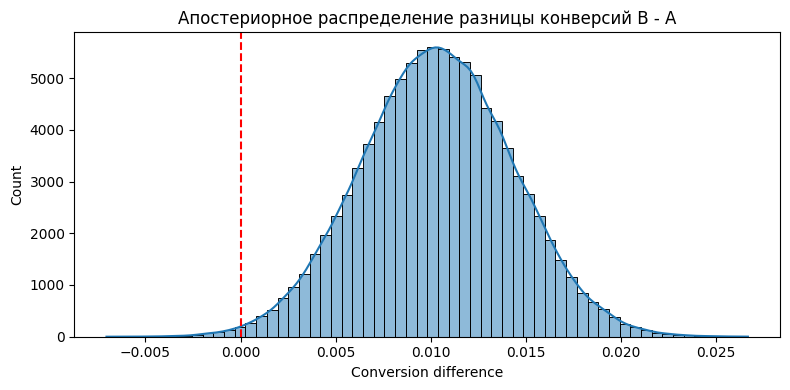

In [ ]:
plt.figure(figsize=(8, 4))
sns.histplot(posterior_diff, bins=60, kde=True)
plt.axvline(0, color="red", linestyle="--")
plt.title("Апостериорное распределение разницы конверсий B - A")
plt.xlabel("Conversion difference")
plt.tight_layout()
plt.show()

## 10. Выводы

В датасете 80 000 пользователей. Базовая конверсия в запуск просмотра не менее 2 минут в течение 10 минут после открытия главного экрана составила 0.2392, то есть 23.92%.

По сегментам активности конверсия различается сильно:

- cold: 14.61%;
- warm: 25.22%;
- hot: 37.76%.

По платформам также есть различия:

- web: 22.31%;
- android: 23.07%;
- ios: 24.82%;
- tv: 27.33%.

Это означает, что активность пользователя и платформа действительно влияют на целевую метрику. Поэтому при запуске реального эксперимента нужно контролировать баланс групп по этим признакам, иначе можно получить искаженный эффект.

### Результат аналитического дизайна

Для основной метрики `watched_2min_within_10min` зафиксированы:

- alpha = 0.05;
- beta = 0.20;
- power = 80%;
- MDE = +5% относительно базовой конверсии;
- baseline conversion = 23.92%;
- target conversion = 25.116%;
- absolute MDE = 1.196 процентного пункта.

`ambrosia` и `statsmodels` дали одинаковый аналитический размер выборки: 20 307 пользователей на группу. С практическим запасом 15% итоговый плановый размер составляет 23 354 пользователя на группу.

При размере 23 354 пользователя на группу `ambrosia` оценила мощность как 0.852, то есть выше требуемых 0.80. Также при таком размере групп минимально детектируемый относительный эффект снижается примерно до 1.047, то есть до +4.7% relative. Это лучше исходного требования +5%.

### Результат эмпирического дизайна

Эмпирическая симуляция мощности показала:

- 13 199 пользователей на группу: power = 0.623;
- 16 245 пользователей на группу: power = 0.712;
- 20 307 пользователей на группу: power = 0.807;
- 23 354 пользователя на группу: power = 0.858;
- 26 399 пользователей на группу: power = 0.891.

Аналитический и эмпирический подходы согласуются: около 20.3 тыс. пользователей на группу уже достаточно для мощности около 80%, но размер с запасом 23.35 тыс. на группу надежнее. Поэтому финальный дизайн эксперимента: A/B 50/50, минимум 20 307 пользователей на группу, планово 23 354 пользователя на группу, длительность 14 дней.

### Рзультат по стратификации и CUPED

Стратификация по `activity_segment` снизила дисперсию выборочного среднего с 0.000182 до 0.000177. Относительное снижение дисперсии составило 2.52%. Эффект не огромный, но полезный: сегменты активности отличаются по конверсии, поэтому их стоит использовать для контроля баланса и диагностики результата.

CUPED для непрерывной метрики `watch_minutes_after_open` дал снижение дисперсии с 609.28 до 605.52, то есть примерно на 0.62%. Это слабый эффект. В данном датасете предэкспериментальная активность не настолько хорошо объясняет постэкспериментальную длительность просмотра, чтобы CUPED сильно ускорил тест. Поэтому CUPED можно оставить как дополнительный анализ для непрерывных guardrail-метрик, но основной дизайн лучше строить по бинарной конверсии.

### Вывод по симулированному A/B результату

Так как реальный продуктовый эксперимент в рамках домашнего задания не запускался, в ноутбуке дополнительно смоделирован пример будущего результата при плановом размере групп.

Получилось:

- группа A: 23 354 пользователя, 5 646 успешных исходов, conversion = 24.18%;
- группа B: 23 354 пользователя, 5 887 успешных исходов, conversion = 25.21%;
- абсолютный эффект: +1.032 процентного пункта;
- относительный эффект: +4.27%;
- p-value = 0.0097;
- 95% доверительный интервал для абсолютного эффекта: [0.250%; 1.814%].

Частотный вывод: эффект статистически значим при alpha = 0.05, потому что p-value < 0.05, а доверительный интервал для абсолютного эффекта положительный. Однако наблюдаемый относительный эффект +4.27% немного ниже заранее выбранного MDE +5%. Поэтому решение не должно быть автоматическим "раскатываем на всех"; нужно дополнительно проверить guardrail-метрики и экономический смысл эффекта.

Байесовская интерпретация по этому же симулированному результату:

- P(B > A) = 0.9954;
- средняя апостериорная разница B - A = 1.032 процентного пункта;
- 95% credible interval = [0.251%; 1.812%];
- ожидаемая потеря при выборе B = 0.000006;
- ожидаемая потеря при выборе A = 0.010328.

С точки зрения бизнес-риска вариант B выглядит предпочтительным: вероятность, что B лучше A, очень высокая, а ожидаемая потеря при выборе B почти нулевая.

### Финальное решение по результатам прогона

По дизайну: выбранный дизайн корректен и реалистичен. Для запуска эксперимента нужно 23 354 пользователя на группу с учетом запаса, split 50/50 по `user_id`, длительность 14 дней, контроль SRM и guardrail-метрик.

По симулированному результату: вариант B можно рекомендовать к осторожной поэтапной раскатке, если guardrail-метрики не ухудшились. Я бы не раскатывал сразу на 100%, потому что эффект статистически значим, но немного ниже MDE. Практическое решение: раскатить на 25% аудитории, 2-3 дня мониторить технические и guardrail-метрики, затем увеличить до 50% и только после стабильного мониторинга раскатывать на всех.


## 11. Правила принятия решения

Решение `раскатываем B`:

- p-value < 0.05;
- эффект положительный;
- доверительный интервал не указывает на существенный риск ухудшения;
- наблюдаемый эффект не ниже или близок к бизнесово полезному MDE;
- guardrail-метрики не ухудшились;
- нет Sample Ratio Mismatch и проблем логирования;
- байесовская проверка показывает высокую вероятность `P(B > A)` и низкие ожидаемые потери при выборе B.

Решение `не раскатываем B`:

- p-value >= 0.05 и эффект мал;
- эффект отрицательный;
- ухудшились guardrail-метрики;
- появились технические ошибки;
- обнаружен SRM или некорректное логирование.

Решение `нужно дополнительное тестирование`:

- эффект положительный, но недостаточно уверенный;
- результат сильно различается по сегментам;
- B помогает hot/warm пользователям, но вредит cold пользователям;
- есть бизнесовый эффект, но выросли краткие просмотры или ухудшилась длительность просмотра.

При множественном анализе сегментов нельзя принимать решения по каждому p-value без поправок. Если заранее хотим проверять несколько сегментов как самостоятельные гипотезы, нужно контролировать FWER или использовать другой заранее зафиксированный подход.